# 3. Bayesian Proportion Estimation

This notebook demonstrates Bayesian inference for proportions using the `BayesianProportionEstimator`.

## Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skpro.regression import BayesianProportionEstimator
from skpro.distributions import Beta

## Example: Coin Flip Experiment

We'll estimate the probability of heads in a coin flip using Bayesian inference with a Beta prior.

## Setting Prior Beliefs

Before any observations, we specify our prior beliefs about the coin's fairness:

In [4]:
# Prior: Beta(alpha=1, beta=1) is uniform - we have no prior preference
prior = Beta(alpha=1.0, beta=1.0)

# Create estimator with this prior
estimator = BayesianProportionEstimator(prior=prior)

print(f"Prior distribution: {prior}")
print(f"Prior mean: {prior.mean():.3f}")
print(f"Prior credible interval: [{prior.ppf(0.025):.3f}, {prior.ppf(0.975):.3f}]")

Prior distribution: Beta(alpha=1.0, beta=1.0)
Prior mean: 0.500
Prior credible interval: [0.025, 0.975]


## Observing Data

Simulation: flip a fair coin 20 times and observe the results:

In [5]:
# Simulate coin flips
np.random.seed(42)
true_prob = 0.5
n_flips = 20

observations = np.random.binomial(1, true_prob, n_flips)
n_heads = observations.sum()
n_tails = n_flips - n_heads

print(f"Results: {n_heads} heads, {n_tails} tails out of {n_flips} flips")
print(f"Empirical proportion: {n_heads/n_flips:.3f}")

Results: 9 heads, 11 tails out of 20 flips
Empirical proportion: 0.450


## Bayesian Updating

Update posterior beliefs based on observed data:

In [10]:
# Prepare data for fitting
X = pd.DataFrame(np.ones(n_flips).reshape(-1, 1), columns=["const"])
y = pd.DataFrame(observations, columns=["outcome"])

# Fit estimator (updates posterior)
estimator.fit(X, y)

# Get posterior distribution
posterior_result = estimator.predict_proba(X.iloc[[0]])
posterior = posterior_result.iloc[0, 0] if hasattr(posterior_result, 'iloc') else posterior_result[0]

print(f"Posterior distribution: {posterior}")
print(f"Posterior mean: {posterior.mean():.3f}")
print(f"Posterior credible interval: [{posterior.ppf(0.025):.3f}, {posterior.ppf(0.975):.3f}]")

Posterior distribution: Beta(alpha=np.float64(10.0), beta=np.float64(12.0))
Posterior mean: 0.455
Posterior credible interval: [0.257, 0.660]


## Visualization: Prior vs Posterior

Compare prior and posterior distributions:

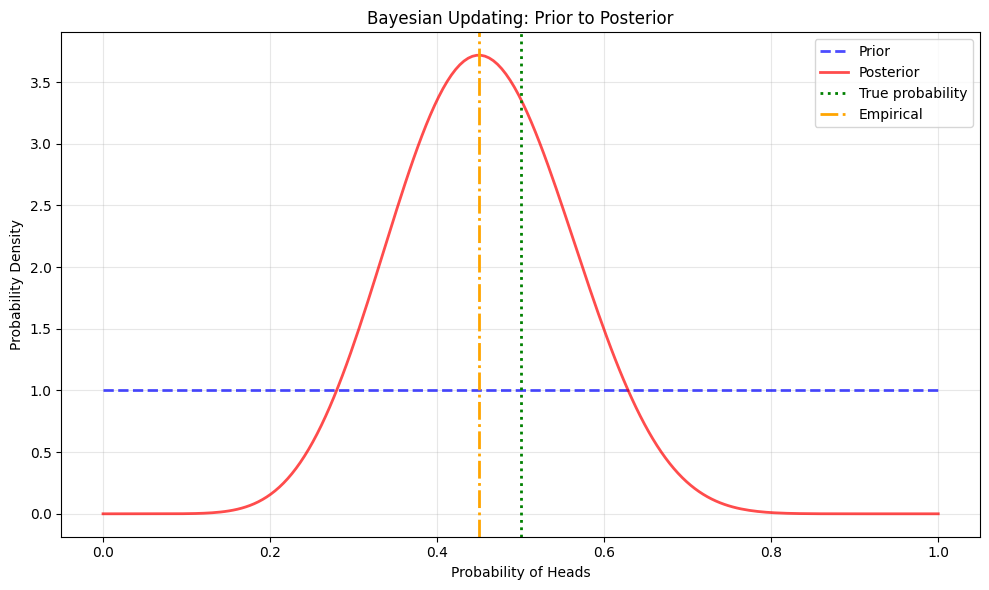

In [12]:
# Create probability support for visualization
x_vals = np.linspace(0, 1, 200)

# Evaluate PDFs
prior_pdf = np.array([prior.pdf(x) for x in x_vals])
posterior_pdf = np.array([posterior.pdf(x) for x in x_vals])

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x_vals, prior_pdf, 'b--', linewidth=2, label='Prior', alpha=0.7)
ax.plot(x_vals, posterior_pdf, 'r-', linewidth=2, label='Posterior', alpha=0.7)
ax.axvline(true_prob, color='g', linestyle=':', linewidth=2, label='True probability')
ax.axvline(n_heads/n_flips, color='orange', linestyle='-.', linewidth=2, label='Empirical')

ax.set_xlabel('Probability of Heads')
ax.set_ylabel('Probability Density')
ax.set_title('Bayesian Updating: Prior to Posterior')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Sequential Updating

Learn how posterior updates with more observations:

In [14]:
# Simulate more coin flips gradually
all_observations = np.random.binomial(1, true_prob, 500)

mean_estimates = []
intervals_lower = []
intervals_upper = []
sample_sizes = [1, 2, 5, 10, 20, 50, 100, 200, 500]

prior_init = Beta(alpha=1.0, beta=1.0)

for n in sample_sizes:
    # Take first n observations
    X_curr = pd.DataFrame(np.ones(n).reshape(-1, 1), columns=["const"])
    y_curr = pd.DataFrame(all_observations[:n], columns=["outcome"])
    
    # Fit and get posterior
    est = BayesianProportionEstimator(prior=prior_init)
    est.fit(X_curr, y_curr)
    posterior_result = est.predict_proba(X_curr.iloc[[0]])
    post = posterior_result.iloc[0, 0] if hasattr(posterior_result, 'iloc') else posterior_result[0]
    
    # Record estimates
    mean_estimates.append(post.mean())
    intervals_lower.append(post.ppf(0.025))
    intervals_upper.append(post.ppf(0.975))

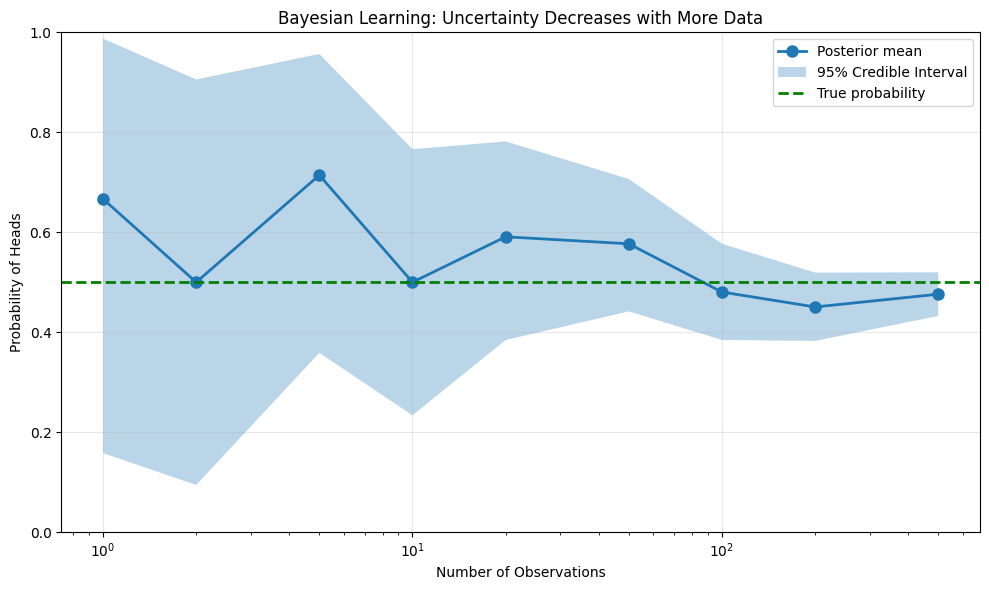

In [15]:
# Plot convergence
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sample_sizes, mean_estimates, 'o-', linewidth=2, markersize=8, label='Posterior mean')
ax.fill_between(sample_sizes, intervals_lower, intervals_upper, 
                 alpha=0.3, label='95% Credible Interval')
ax.axhline(true_prob, color='g', linestyle='--', linewidth=2, label='True probability')

ax.set_xlabel('Number of Observations')
ax.set_ylabel('Probability of Heads')
ax.set_title('Bayesian Learning: Uncertainty Decreases with More Data')
ax.set_xscale('log')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

## Key Takeaways

- **Bayesian inference** combines prior beliefs with data to form posterior beliefs
- **Beta-Binomial conjugacy** enables closed-form posterior computation
- **Uncertainty decreases** as we observe more data
- **Prior matters** when data is limited, becomes less important with more data